In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path("/Users/littlestars/Desktop/grain_project")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
RESULTS_DIR = BASE_DIR / "results"
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

panel_path = PROCESSED_DIR / "final_panel_with_spi.csv"
climate_path = PROCESSED_DIR / "climate_yearly_with_spi.csv"
zone_panel_path = PROCESSED_DIR / "final_panel_regression_ready_with_zone.csv"

panel = pd.read_csv(panel_path, encoding="utf-8-sig")
climate = pd.read_csv(climate_path, encoding="utf-8-sig")

print("panel:", panel.shape)
print("climate:", climate.shape)

display(panel.head())
display(climate.head())

print("panel columns:")
print(panel.columns.tolist())

panel: (1170, 21)
climate: (1275, 4)


,region,region_std,year,production,area_total,temp_annual_mean,prec_annual_sum,temp_grow_mean,prec_grow_sum,prec_winter_sum,...,prec_annual_lag1,temp_grow_lag1,prec_grow_lag1,ln_production,ln_area,temp_grow_sq,prec_grow_sq,agro_zone,spi_grow_mean,spi_grow_min
0,Алтайский край,Алтайский край,2007,4698310.0,3576.553,4.392201,18500.683351,14.966577,11828.601908,2947.105955,...,NaN,NaN,NaN,15.362713,8.182155,223.998427,1.399158e+08,black_soil,1.049620,-0.838191
1,Алтайский край,Алтайский край,2008,3857490.0,3781.666,3.697218,15796.192706,14.458340,9664.188503,4763.213377,...,18500.683351,14.966577,11828.601908,15.165527,8.237920,209.043593,9.339654e+07,black_soil,0.114225,-0.451164
2,Алтайский край,Алтайский край,2009,5627845.0,3803.968,2.031430,19978.352155,13.675152,12172.945430,5920.012841,...,15796.192706,14.458340,9664.188503,15.543237,8.243800,187.009776,1.481806e+08,black_soil,0.882891,-0.834674
3,Алтайский край,Алтайский край,2010,4240800.0,3393.564,1.010635,15814.163267,13.087710,7716.307153,5875.486827,...,19978.352155,13.675152,12172.945430,15.260262,8.129636,171.288150,5.954140e+07,black_soil,-0.047701,-0.792166
4,Алтайский край,Алтайский край,2011,3919500.0,3628.322,2.650180,12728.997058,14.869391,7859.059347,5885.648386,...,15814.163267,13.087710,7716.307153,15.181475,8.196526,221.098799,6.176481e+07,black_soil,-0.286207,-0.980573


,region_std,year,spi_grow_mean,spi_grow_min
0,Алтайский край,2007,1.049620,-0.838191
1,Алтайский край,2008,0.114225,-0.451164
2,Алтайский край,2009,0.882891,-0.834674
3,Алтайский край,2010,-0.047701,-0.792166
4,Алтайский край,2011,-0.286207,-0.980573


panel columns:
['region', 'region_std', 'year', 'production', 'area_total', 'temp_annual_mean', 'prec_annual_sum', 'temp_grow_mean', 'prec_grow_sum', 'prec_winter_sum', 'temp_annual_lag1', 'prec_annual_lag1', 'temp_grow_lag1', 'prec_grow_lag1', 'ln_production', 'ln_area', 'temp_grow_sq', 'prec_grow_sq', 'agro_zone', 'spi_grow_mean', 'spi_grow_min']


In [21]:
def normalize_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    rename_map = {}

    for c in df.columns:
        lc = c.lower()

        if lc in ["year", "год"]:
            rename_map[c] = "year"
        elif lc in ["region", "subject", "name", "регион"]:
            rename_map[c] = "region"
        elif lc in ["production", "grain_production", "grain production", "prod", "yield"]:
            rename_map[c] = "production"
        elif lc in ["ln_production", "log_production", "ln_y"]:
            rename_map[c] = "ln_production"
        elif lc in ["area", "grain_area", "sown_area", "sowing_area", "grain_sown_area"]:
            rename_map[c] = "area"
        elif lc in ["ln_area", "log_area", "ln_a"]:
            rename_map[c] = "ln_area"
        elif lc in ["temp_grow_mean", "growing_temp", "grow_temp", "temp_growing_season"]:
            rename_map[c] = "temp_grow_mean"
        elif lc in ["prec_grow_sum", "precip_grow_sum", "growing_precip", "precipitation_growing_season"]:
            rename_map[c] = "prec_grow_sum"
        elif lc in ["spi_grow_mean", "spi", "grow_spi", "spi_growing_season"]:
            rename_map[c] = "spi_grow_mean"
        elif lc in ["spei_grow_mean", "spei", "grow_spei", "spei_growing_season"]:
            rename_map[c] = "spei_grow_mean"
        elif lc in ["zone", "agro_zone", "agricultural_zone"]:
            rename_map[c] = "zone"

    df = df.rename(columns=rename_map)

    if "ln_production" not in df.columns and "production" in df.columns:
        df["ln_production"] = np.where(df["production"] > 0, np.log(df["production"]), np.nan)

    if "ln_area" not in df.columns and "area" in df.columns:
        df["ln_area"] = np.where(df["area"] > 0, np.log(df["area"]), np.nan)

    return df

panel = normalize_columns(panel)
climate = normalize_columns(climate)

print(panel.columns.tolist())
display(panel.head())

['region', 'region_std', 'year', 'production', 'area_total', 'temp_annual_mean', 'prec_annual_sum', 'temp_grow_mean', 'prec_grow_sum', 'prec_winter_sum', 'temp_annual_lag1', 'prec_annual_lag1', 'temp_grow_lag1', 'prec_grow_lag1', 'ln_production', 'ln_area', 'temp_grow_sq', 'prec_grow_sq', 'zone', 'spi_grow_mean', 'spi_grow_min']


,region,region_std,year,production,area_total,temp_annual_mean,prec_annual_sum,temp_grow_mean,prec_grow_sum,prec_winter_sum,...,prec_annual_lag1,temp_grow_lag1,prec_grow_lag1,ln_production,ln_area,temp_grow_sq,prec_grow_sq,zone,spi_grow_mean,spi_grow_min
0,Алтайский край,Алтайский край,2007,4698310.0,3576.553,4.392201,18500.683351,14.966577,11828.601908,2947.105955,...,NaN,NaN,NaN,15.362713,8.182155,223.998427,1.399158e+08,black_soil,1.049620,-0.838191
1,Алтайский край,Алтайский край,2008,3857490.0,3781.666,3.697218,15796.192706,14.458340,9664.188503,4763.213377,...,18500.683351,14.966577,11828.601908,15.165527,8.237920,209.043593,9.339654e+07,black_soil,0.114225,-0.451164
2,Алтайский край,Алтайский край,2009,5627845.0,3803.968,2.031430,19978.352155,13.675152,12172.945430,5920.012841,...,15796.192706,14.458340,9664.188503,15.543237,8.243800,187.009776,1.481806e+08,black_soil,0.882891,-0.834674
3,Алтайский край,Алтайский край,2010,4240800.0,3393.564,1.010635,15814.163267,13.087710,7716.307153,5875.486827,...,19978.352155,13.675152,12172.945430,15.260262,8.129636,171.288150,5.954140e+07,black_soil,-0.047701,-0.792166
4,Алтайский край,Алтайский край,2011,3919500.0,3628.322,2.650180,12728.997058,14.869391,7859.059347,5885.648386,...,15814.163267,13.087710,7716.307153,15.181475,8.196526,221.098799,6.176481e+07,black_soil,-0.286207,-0.980573


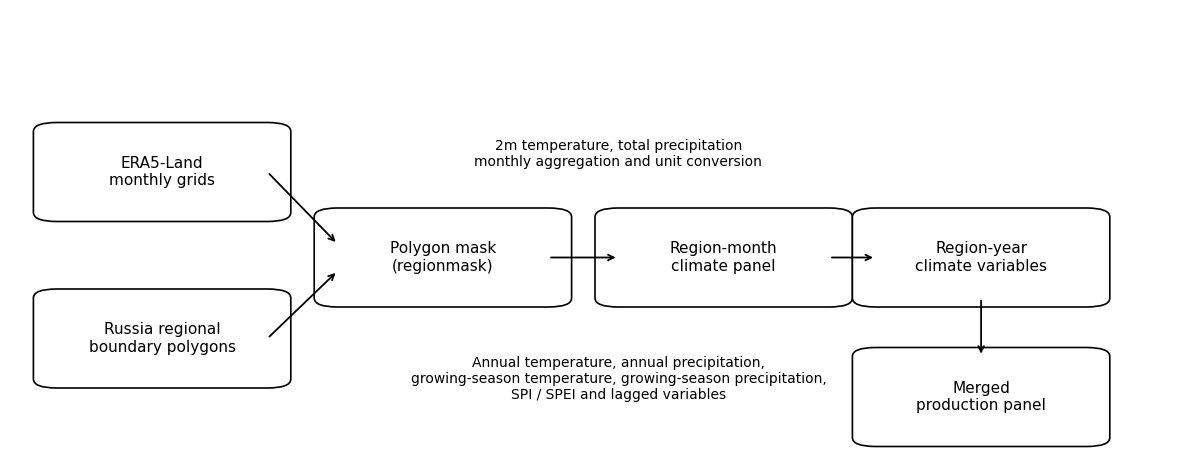

Saved: /Users/littlestars/Desktop/grain_project/figures/fig1_climate_data_workflow.png


In [23]:
def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


def plot_workflow():
    fig, ax = plt.subplots(figsize=(12, 4.8))
    ax.axis("off")
    
    boxes = [
        ("ERA5-Land\nmonthly grids", 0.04, 0.55),
        ("Russia regional\nboundary polygons", 0.04, 0.18),
        ("Polygon mask\n(regionmask)", 0.28, 0.36),
        ("Region-month\nclimate panel", 0.52, 0.36),
        ("Region-year\nclimate variables", 0.74, 0.36),
        ("Merged\nproduction panel", 0.74, 0.05),
    ]
    
    box_w = 0.18
    box_h = 0.18
    
    for text, x, y in boxes:
        patch = FancyBboxPatch(
            (x, y),
            box_w,
            box_h,
            boxstyle="round,pad=0.02",
            linewidth=1.2,
            facecolor="white",
            edgecolor="black",
        )
        ax.add_patch(patch)
        ax.text(x + box_w / 2, y + box_h / 2, text, ha="center", va="center", fontsize=11)
    
    arrows = [
        ((0.22, 0.64), (0.28, 0.48)),
        ((0.22, 0.27), (0.28, 0.42)),
        ((0.46, 0.45), (0.52, 0.45)),
        ((0.70, 0.45), (0.74, 0.45)),
        ((0.83, 0.36), (0.83, 0.23)),
    ]
    
    for start, end in arrows:
        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(arrowstyle="->", linewidth=1.3),
        )
    
    ax.text(
        0.52,
        0.68,
        "2m temperature, total precipitation\nmonthly aggregation and unit conversion",
        ha="center",
        va="center",
        fontsize=10,
    )
    
    ax.text(
        0.52,
        0.18,
        "Annual temperature, annual precipitation,\n"
        "growing-season temperature, growing-season precipitation,\n"
        "SPI / SPEI and lagged variables",
        ha="center",
        va="center",
        fontsize=10,
    )
    
    savefig("fig1_climate_data_workflow.png")


plot_workflow()

,year,ln_production,ln_area,temp_grow_mean,spi_grow_mean
0,2007,12.579054,5.198692,13.875530,0.467264
1,2008,12.752193,5.238995,13.158444,0.732148
2,2009,12.677545,5.191704,12.995621,0.348075
3,2010,12.330447,5.218729,15.005113,-0.226743
4,2011,12.765645,5.243200,13.772215,0.398352


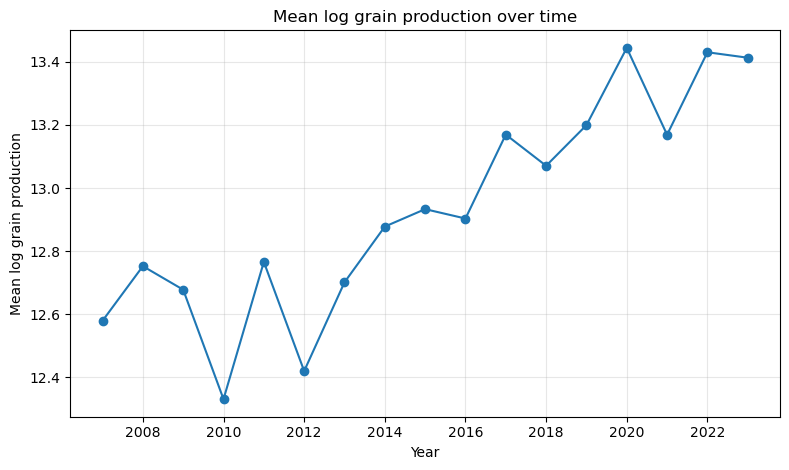

Saved: /Users/littlestars/Desktop/grain_project/figures/trend_ln_production.png


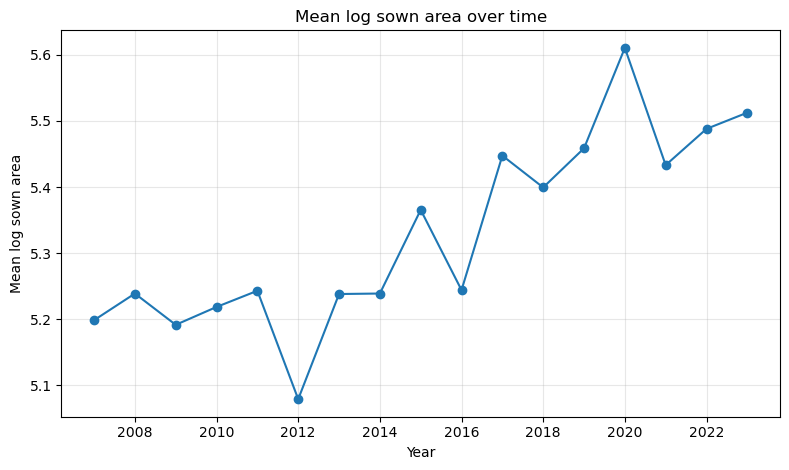

Saved: /Users/littlestars/Desktop/grain_project/figures/trend_ln_area.png


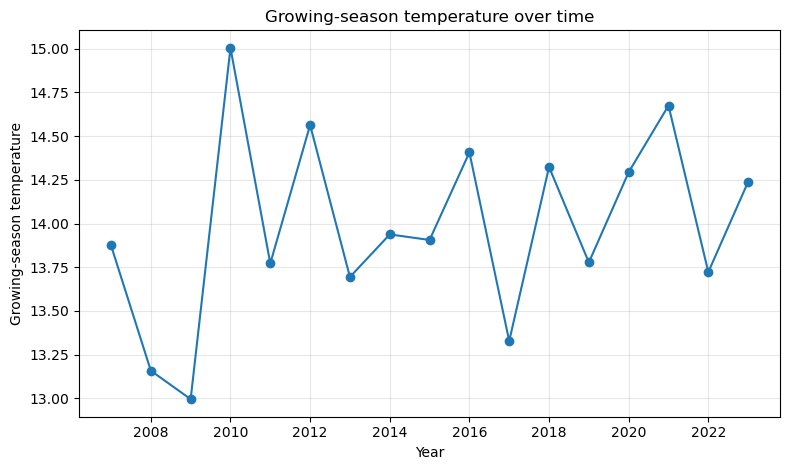

Saved: /Users/littlestars/Desktop/grain_project/figures/trend_temp_grow_mean.png


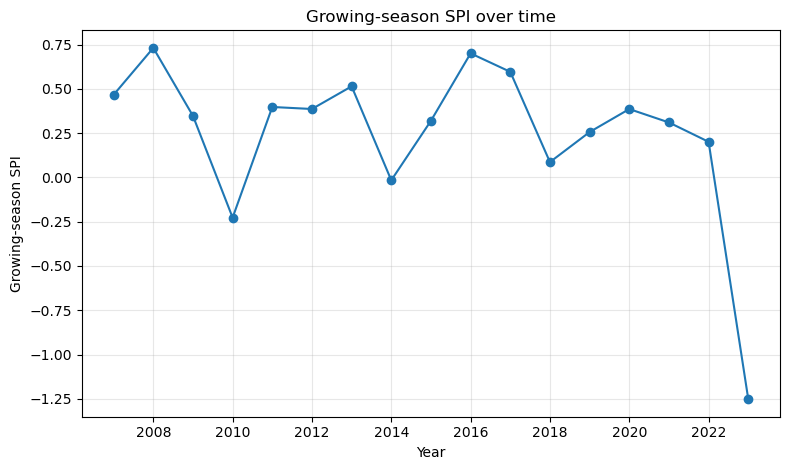

Saved: /Users/littlestars/Desktop/grain_project/figures/trend_spi_grow_mean.png


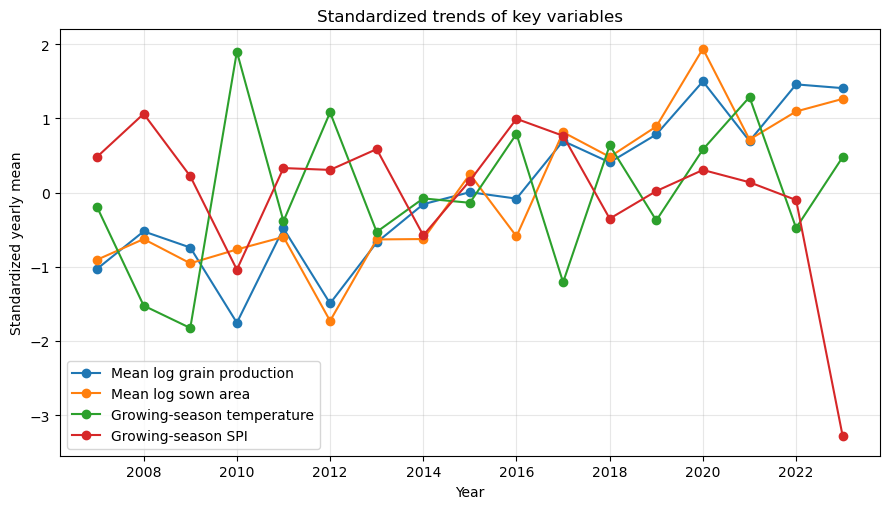

Saved: /Users/littlestars/Desktop/grain_project/figures/fig2_variable_trends.png


In [25]:
def plot_variable_trends(df):
    if df is None:
        print("No panel data.")
        return
    
    if "year" not in df.columns:
        print("No year column.")
        return
    
    variables = []
    
    if "ln_production" in df.columns:
        variables.append(("ln_production", "Mean log grain production"))
    
    if "ln_area" in df.columns:
        variables.append(("ln_area", "Mean log sown area"))
    
    if "temp_grow_mean" in df.columns:
        variables.append(("temp_grow_mean", "Growing-season temperature"))
    
    if "spi_grow_mean" in df.columns:
        variables.append(("spi_grow_mean", "Growing-season SPI"))
    
    if "spei_grow_mean" in df.columns:
        variables.append(("spei_grow_mean", "Growing-season SPEI"))
    
    if not variables:
        print("No key variables found.")
        return
    
    yearly = df.groupby("year")[[v[0] for v in variables]].mean(numeric_only=True).reset_index()
    display(yearly.head())
    
    # 单变量趋势图
    for var, title in variables:
        plt.figure(figsize=(8, 4.8))
        plt.plot(yearly["year"], yearly[var], marker="o")
        plt.xlabel("Year")
        plt.ylabel(title)
        plt.title(title + " over time")
        plt.grid(True, alpha=0.3)
        savefig(f"trend_{var}.png")
    
    # 标准化综合趋势图
    z = yearly.copy()
    for var, _ in variables:
        std = z[var].std()
        if std and not np.isnan(std):
            z[var] = (z[var] - z[var].mean()) / std
    
    plt.figure(figsize=(9, 5.2))
    for var, title in variables:
        plt.plot(z["year"], z[var], marker="o", label=title)
    
    plt.xlabel("Year")
    plt.ylabel("Standardized yearly mean")
    plt.title("Standardized trends of key variables")
    plt.legend()
    plt.grid(True, alpha=0.3)
    savefig("fig2_variable_trends.png")


plot_variable_trends(panel)

In [27]:
def make_descriptive_table(df):
    if df is None:
        print("No panel data.")
        return
    
    candidate_vars = [
        "ln_production",
        "ln_area",
        "temp_grow_mean",
        "prec_grow_sum",
        "spi_grow_mean",
        "spei_grow_mean",
    ]
    
    use_vars = [v for v in candidate_vars if v in df.columns]
    
    if not use_vars:
        print("No variables found.")
        return
    
    desc = df[use_vars].describe().T
    desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
    
    out = FIG_DIR / "table_descriptive_statistics.csv"
    desc.to_csv(out, encoding="utf-8-sig")
    
    print("Saved:", out)
    display(desc)


make_descriptive_table(panel)

Saved: /Users/littlestars/Desktop/grain_project/figures/table_descriptive_statistics.csv


,count,mean,std,min,25%,50%,75%,max
ln_production,1170.0,12.922748,2.184030,2.302585,11.860054,13.222678,14.548971,16.598687
ln_area,1170.0,5.326070,2.019288,-4.828314,4.418998,5.491108,6.846224,8.243800
temp_grow_mean,1170.0,13.978768,3.613353,3.140021,12.170721,14.237210,16.166216,22.884283
prec_grow_sum,1170.0,11850.522903,4868.641908,2013.581375,8912.990579,11465.263922,14040.422579,32814.491818
spi_grow_mean,1170.0,0.254347,0.677890,-2.125848,-0.138294,0.350961,0.695953,2.028917


In [29]:
core_results = pd.DataFrame([
    # model, variable, coef, se, pvalue
    
    ("Baseline FE", "Temperature", -0.1101, 0.0231, 0.0000),
    ("Baseline FE", "SPI",          0.0424, 0.0273, 0.1213),
    
    ("Dynamic FE", "Lagged log production", 0.4276, 0.0488, 0.0000),
    ("Dynamic FE", "Temperature",          -0.0976, 0.0161, 0.0000),
    ("Dynamic FE", "SPI",                   0.0586, 0.0237, 0.0137),
    
    ("Quadratic FE", "Temperature", -0.0495, 0.1182, 0.6755),
    ("Quadratic FE", "SPI",          0.0719, 0.0295, 0.0150),
    ("Quadratic FE", "SPI squared", -0.0710, 0.0216, 0.0011),
    
    ("Quantile 0.25", "SPI", 0.0805, 0.0190, 0.0000),
    ("Quantile 0.50", "SPI", 0.0505, np.nan, np.nan),
    ("Quantile 0.75", "SPI", 0.0500, np.nan, np.nan),
], columns=["model", "variable", "coef", "se", "pvalue"])

core_results["ci_low"] = core_results["coef"] - 1.96 * core_results["se"]
core_results["ci_high"] = core_results["coef"] + 1.96 * core_results["se"]

out = FIG_DIR / "table_model_key_results.csv"
core_results.to_csv(out, index=False, encoding="utf-8-sig")

print("Saved:", out)
display(core_results)

Saved: /Users/littlestars/Desktop/grain_project/figures/table_model_key_results.csv


,model,variable,coef,se,pvalue,ci_low,ci_high
0,Baseline FE,Temperature,-0.1101,0.0231,0.0000,-0.155376,-0.064824
1,Baseline FE,SPI,0.0424,0.0273,0.1213,-0.011108,0.095908
2,Dynamic FE,Lagged log production,0.4276,0.0488,0.0000,0.331952,0.523248
3,Dynamic FE,Temperature,-0.0976,0.0161,0.0000,-0.129156,-0.066044
4,Dynamic FE,SPI,0.0586,0.0237,0.0137,0.012148,0.105052
5,Quadratic FE,Temperature,-0.0495,0.1182,0.6755,-0.281172,0.182172
6,Quadratic FE,SPI,0.0719,0.0295,0.0150,0.014080,0.129720
7,Quadratic FE,SPI squared,-0.0710,0.0216,0.0011,-0.113336,-0.028664
8,Quantile 0.25,SPI,0.0805,0.0190,0.0000,0.043260,0.117740
9,Quantile 0.50,SPI,0.0505,NaN,NaN,NaN,NaN


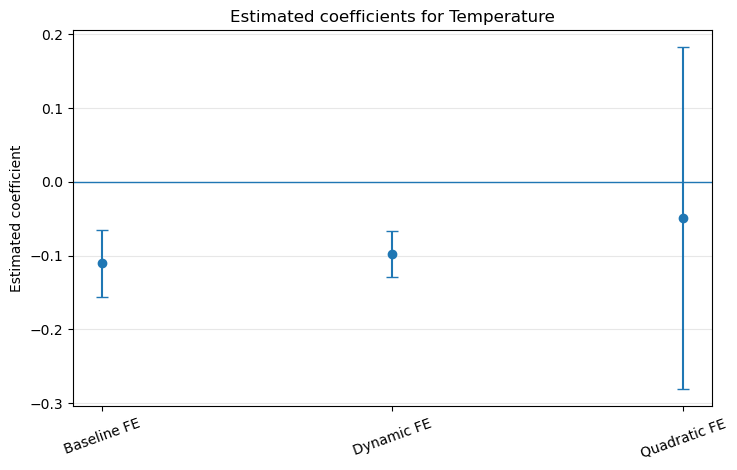

Saved: /Users/littlestars/Desktop/grain_project/figures/fig3_model_coefficients_temperature.png


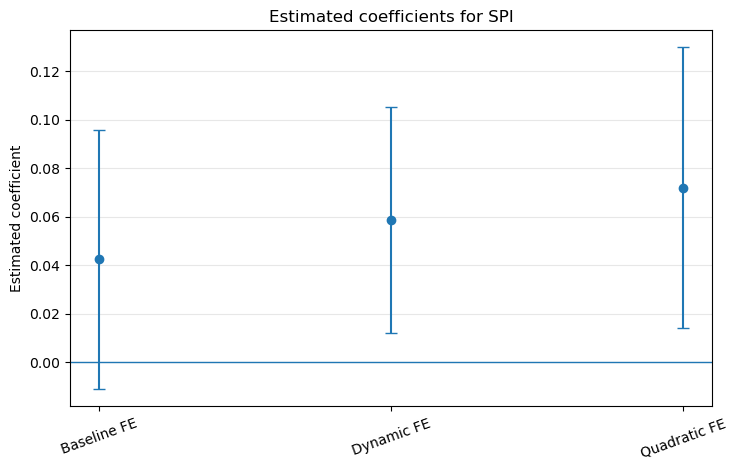

Saved: /Users/littlestars/Desktop/grain_project/figures/fig3_model_coefficients_spi.png


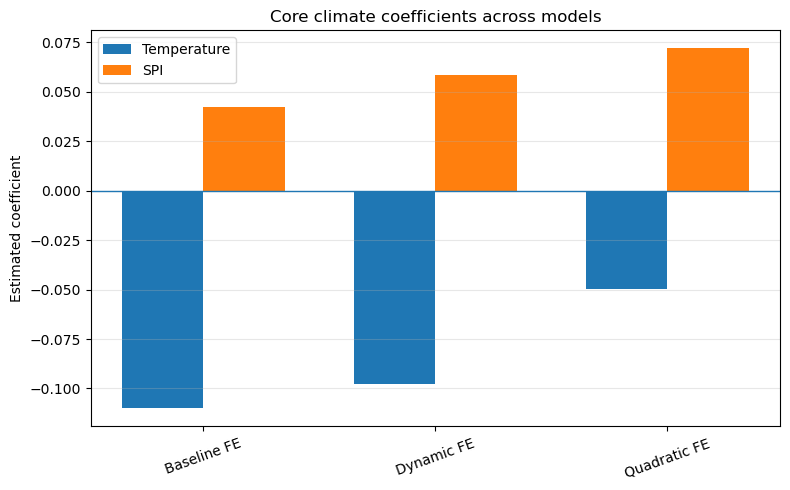

Saved: /Users/littlestars/Desktop/grain_project/figures/fig3_model_coefficients.png


In [31]:
def plot_model_coefficients(df):
    plot_df = df[df["variable"].isin(["Temperature", "SPI"])].copy()
    plot_df = plot_df[plot_df["model"].isin(["Baseline FE", "Dynamic FE", "Quadratic FE"])]
    
    if plot_df.empty:
        print("No model coefficients.")
        return
    
    # 温度和 SPI 分别画
    for var in ["Temperature", "SPI"]:
        sub = plot_df[plot_df["variable"] == var].copy()
        if sub.empty:
            continue
        
        sub["x"] = np.arange(len(sub))
        
        plt.figure(figsize=(7.5, 4.8))
        yerr = 1.96 * sub["se"]
        plt.errorbar(sub["x"], sub["coef"], yerr=yerr, fmt="o", capsize=4)
        plt.axhline(0, linewidth=1)
        plt.xticks(sub["x"], sub["model"], rotation=20)
        plt.ylabel("Estimated coefficient")
        plt.title(f"Estimated coefficients for {var}")
        plt.grid(True, axis="y", alpha=0.3)
        savefig(f"fig3_model_coefficients_{var.lower().replace(' ', '_')}.png")
    
    # 综合柱状图
    temp = plot_df[plot_df["variable"] == "Temperature"].set_index("model")
    spi = plot_df[plot_df["variable"] == "SPI"].set_index("model")
    
    models = ["Baseline FE", "Dynamic FE", "Quadratic FE"]
    x = np.arange(len(models))
    width = 0.35
    
    plt.figure(figsize=(8, 5))
    plt.bar(
        x - width / 2,
        [temp.loc[m, "coef"] if m in temp.index else np.nan for m in models],
        width,
        label="Temperature",
    )
    plt.bar(
        x + width / 2,
        [spi.loc[m, "coef"] if m in spi.index else np.nan for m in models],
        width,
        label="SPI",
    )
    
    plt.axhline(0, linewidth=1)
    plt.xticks(x, models, rotation=20)
    plt.ylabel("Estimated coefficient")
    plt.title("Core climate coefficients across models")
    plt.legend()
    plt.grid(True, axis="y", alpha=0.3)
    savefig("fig3_model_coefficients.png")


plot_model_coefficients(core_results)

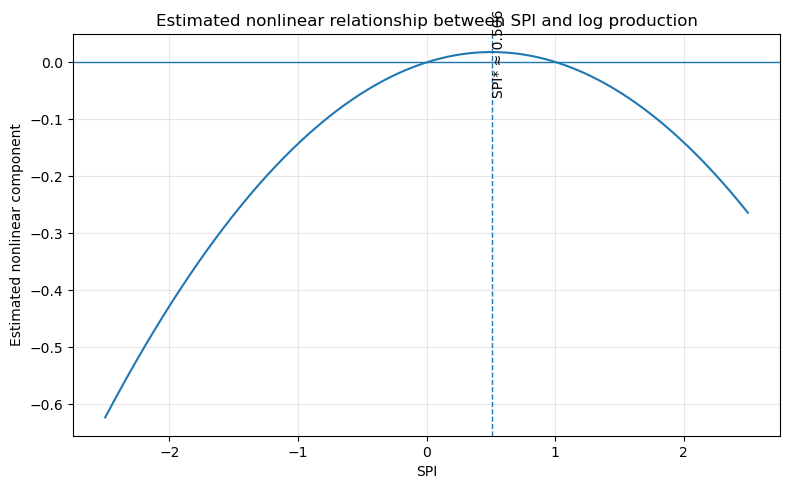

Saved: /Users/littlestars/Desktop/grain_project/figures/fig4_spi_nonlinear_effect.png


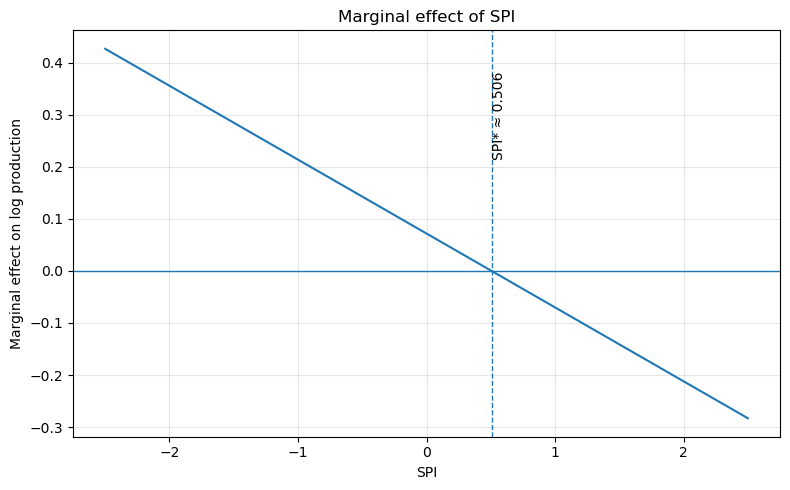

Saved: /Users/littlestars/Desktop/grain_project/figures/fig4_spi_marginal_effect.png


In [33]:
def plot_spi_nonlinear_effect(beta_spi=0.0719, beta_spi2=-0.0710):
    spi_star = -beta_spi / (2 * beta_spi2)
    
    spi_grid = np.linspace(-2.5, 2.5, 300)
    nonlinear_component = beta_spi * spi_grid + beta_spi2 * spi_grid ** 2
    marginal_effect = beta_spi + 2 * beta_spi2 * spi_grid
    
    # 非线性曲线
    plt.figure(figsize=(8, 5))
    plt.plot(spi_grid, nonlinear_component)
    plt.axvline(spi_star, linestyle="--", linewidth=1)
    plt.axhline(0, linewidth=1)
    plt.xlabel("SPI")
    plt.ylabel("Estimated nonlinear component")
    plt.title("Estimated nonlinear relationship between SPI and log production")
    plt.text(
        spi_star,
        np.nanmax(nonlinear_component) * 0.8,
        f"SPI* ≈ {spi_star:.3f}",
        rotation=90,
        va="center",
    )
    plt.grid(True, alpha=0.3)
    savefig("fig4_spi_nonlinear_effect.png")
    
    # 边际效应图
    plt.figure(figsize=(8, 5))
    plt.plot(spi_grid, marginal_effect)
    plt.axvline(spi_star, linestyle="--", linewidth=1)
    plt.axhline(0, linewidth=1)
    plt.xlabel("SPI")
    plt.ylabel("Marginal effect on log production")
    plt.title("Marginal effect of SPI")
    plt.text(
        spi_star,
        np.nanmax(marginal_effect) * 0.7,
        f"SPI* ≈ {spi_star:.3f}",
        rotation=90,
        va="center",
    )
    plt.grid(True, alpha=0.3)
    savefig("fig4_spi_marginal_effect.png")


plot_spi_nonlinear_effect()

,quantile,coef,se,ci_low,ci_high
0,0.25,0.0805,0.019,0.04326,0.11774
1,0.50,0.0505,NaN,NaN,NaN
2,0.75,0.0500,NaN,NaN,NaN


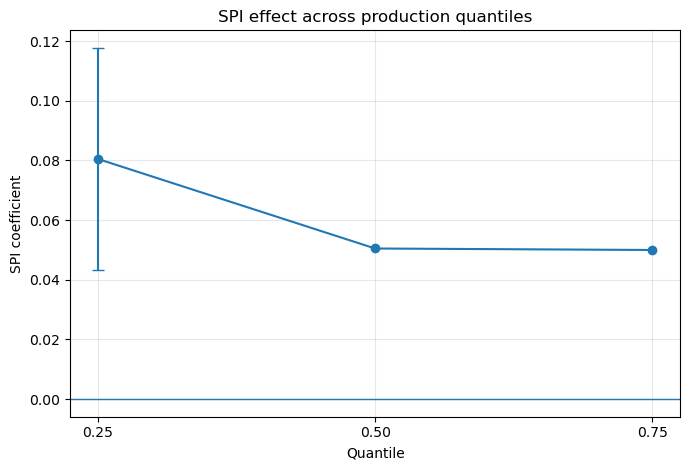

Saved: /Users/littlestars/Desktop/grain_project/figures/fig5_quantile_spi_coefficients.png


In [35]:
def plot_quantile_coefficients():
    q_df = pd.DataFrame({
        "quantile": [0.25, 0.50, 0.75],
        "coef": [0.0805, 0.0505, 0.0500],
        # 目前只确定 q=0.25 的标准误，后续可补 q=0.5 和 q=0.75
        "se": [0.0190, np.nan, np.nan],
    })
    
    q_df["ci_low"] = q_df["coef"] - 1.96 * q_df["se"]
    q_df["ci_high"] = q_df["coef"] + 1.96 * q_df["se"]
    
    display(q_df)
    
    plt.figure(figsize=(7, 4.8))
    plt.plot(q_df["quantile"], q_df["coef"], marker="o")
    plt.axhline(0, linewidth=1)
    
    known = q_df.dropna(subset=["se"])
    if not known.empty:
        plt.errorbar(
            known["quantile"],
            known["coef"],
            yerr=1.96 * known["se"],
            fmt="none",
            capsize=4,
        )
    
    plt.xlabel("Quantile")
    plt.ylabel("SPI coefficient")
    plt.title("SPI effect across production quantiles")
    plt.xticks([0.25, 0.50, 0.75])
    plt.grid(True, alpha=0.3)
    savefig("fig5_quantile_spi_coefficients.png")


plot_quantile_coefficients()

In [37]:
zone_results = pd.DataFrame([
    # zone, variable, coef, se, pvalue, nobs
    
    ("Black soil", "Temperature", -0.0112, 0.0598, 0.8515, 110),
    ("Black soil", "SPI",          0.2986, 0.0816, 0.0004, 110),
    
    ("Volga dry", "Temperature", -0.0569, 0.0327, 0.0841, 195),
    ("Volga dry", "SPI",         -0.0263, 0.0644, 0.6833, 195),
    
    ("Other", "Temperature", -0.0688, 0.0189, 0.0003, 588),
    ("Other", "SPI",          0.0556, 0.0352, 0.1141, 588),
    
    ("Risky farming", "Temperature", -0.1167, 0.0561, 0.0391, 206),
    ("Risky farming", "SPI",          0.0722, 0.0552, 0.1925, 206),
], columns=["zone", "variable", "coef", "se", "pvalue", "nobs"])

zone_results["ci_low"] = zone_results["coef"] - 1.96 * zone_results["se"]
zone_results["ci_high"] = zone_results["coef"] + 1.96 * zone_results["se"]

out = FIG_DIR / "table_zone_heterogeneity.csv"
zone_results.to_csv(out, index=False, encoding="utf-8-sig")

print("Saved:", out)
display(zone_results)

Saved: /Users/littlestars/Desktop/grain_project/figures/table_zone_heterogeneity.csv


,zone,variable,coef,se,pvalue,nobs,ci_low,ci_high
0,Black soil,Temperature,-0.0112,0.0598,0.8515,110,-0.128408,0.106008
1,Black soil,SPI,0.2986,0.0816,0.0004,110,0.138664,0.458536
2,Volga dry,Temperature,-0.0569,0.0327,0.0841,195,-0.120992,0.007192
3,Volga dry,SPI,-0.0263,0.0644,0.6833,195,-0.152524,0.099924
4,Other,Temperature,-0.0688,0.0189,0.0003,588,-0.105844,-0.031756
5,Other,SPI,0.0556,0.0352,0.1141,588,-0.013392,0.124592
6,Risky farming,Temperature,-0.1167,0.0561,0.0391,206,-0.226656,-0.006744
7,Risky farming,SPI,0.0722,0.0552,0.1925,206,-0.035992,0.180392


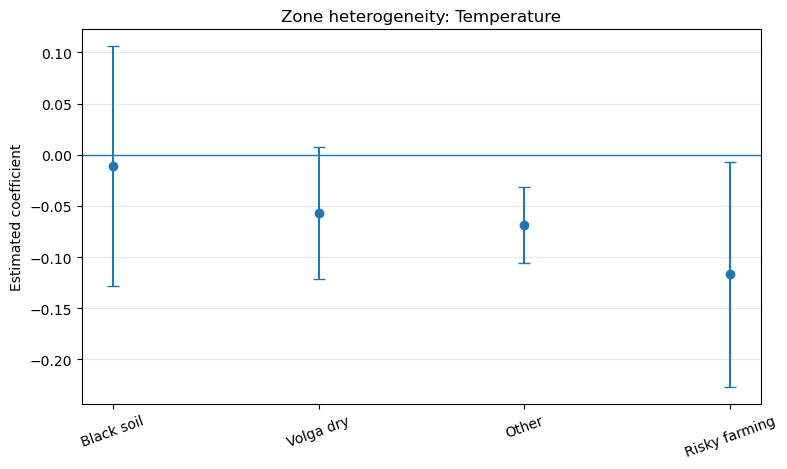

Saved: /Users/littlestars/Desktop/grain_project/figures/fig6_zone_heterogeneity_temperature.png


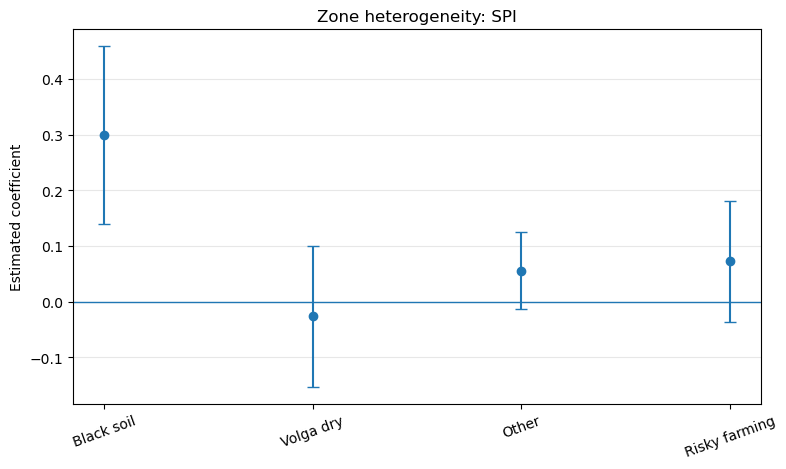

Saved: /Users/littlestars/Desktop/grain_project/figures/fig6_zone_heterogeneity_spi.png


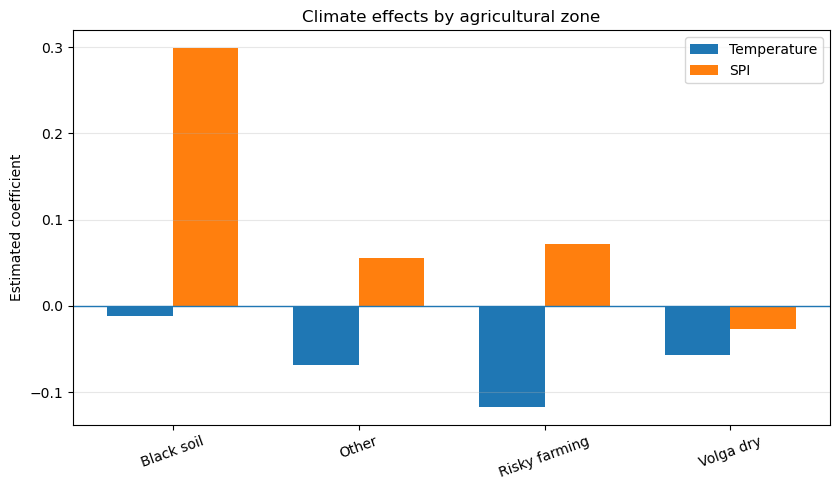

Saved: /Users/littlestars/Desktop/grain_project/figures/fig6_zone_heterogeneity.png


In [39]:
def plot_zone_heterogeneity(z):
    for var in ["Temperature", "SPI"]:
        sub = z[z["variable"] == var].copy()
        sub["x"] = np.arange(len(sub))
        
        plt.figure(figsize=(8, 4.8))
        plt.errorbar(
            sub["x"],
            sub["coef"],
            yerr=1.96 * sub["se"],
            fmt="o",
            capsize=4,
        )
        plt.axhline(0, linewidth=1)
        plt.xticks(sub["x"], sub["zone"], rotation=20)
        plt.ylabel("Estimated coefficient")
        plt.title(f"Zone heterogeneity: {var}")
        plt.grid(True, axis="y", alpha=0.3)
        savefig(f"fig6_zone_heterogeneity_{var.lower().replace(' ', '_')}.png")
    
    pivot = z.pivot(index="zone", columns="variable", values="coef")
    zones = pivot.index.tolist()
    x = np.arange(len(zones))
    width = 0.35
    
    plt.figure(figsize=(8.5, 5))
    plt.bar(x - width / 2, pivot["Temperature"], width, label="Temperature")
    plt.bar(x + width / 2, pivot["SPI"], width, label="SPI")
    plt.axhline(0, linewidth=1)
    plt.xticks(x, zones, rotation=20)
    plt.ylabel("Estimated coefficient")
    plt.title("Climate effects by agricultural zone")
    plt.legend()
    plt.grid(True, axis="y", alpha=0.3)
    savefig("fig6_zone_heterogeneity.png")


plot_zone_heterogeneity(zone_results)

In [41]:
def plot_simple_region_scatter_map(df):
    if df is None:
        print("No panel data.")
        return
    
    lon_candidates = ["lon", "longitude", "lng", "centroid_lon", "x"]
    lat_candidates = ["lat", "latitude", "centroid_lat", "y"]
    
    lon_col = next((c for c in lon_candidates if c in df.columns), None)
    lat_col = next((c for c in lat_candidates if c in df.columns), None)
    
    if lon_col is None or lat_col is None:
        print("No longitude/latitude columns found.")
        print("Available columns:")
        print(df.columns.tolist())
        return
    
    if "region" in df.columns:
        cols = [lon_col, lat_col]
        if "ln_production" in df.columns:
            cols.append("ln_production")
        g = df.groupby("region")[cols].mean(numeric_only=True).reset_index()
    else:
        g = df[[lon_col, lat_col, "ln_production"]].dropna().copy()
    
    plt.figure(figsize=(8, 5.5))
    
    if "ln_production" in g.columns:
        sc = plt.scatter(g[lon_col], g[lat_col], c=g["ln_production"], s=35)
        plt.colorbar(sc, label="Mean log production")
    else:
        plt.scatter(g[lon_col], g[lat_col], s=35)
    
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Sample regions")
    plt.grid(True, alpha=0.3)
    savefig("fig7_region_centroid_map.png")


plot_simple_region_scatter_map(panel)

No longitude/latitude columns found.
Available columns:
['region', 'region_std', 'year', 'production', 'area_total', 'temp_annual_mean', 'prec_annual_sum', 'temp_grow_mean', 'prec_grow_sum', 'prec_winter_sum', 'temp_annual_lag1', 'prec_annual_lag1', 'temp_grow_lag1', 'prec_grow_lag1', 'ln_production', 'ln_area', 'temp_grow_sq', 'prec_grow_sq', 'zone', 'spi_grow_mean', 'spi_grow_min']


In [43]:
def plot_polygon_map(panel_df, shapefile_path):
    import geopandas as gpd
    
    shapefile_path = Path(shapefile_path)
    
    if not shapefile_path.exists():
        print("Shapefile not found:", shapefile_path)
        return
    
    if panel_df is None or "region" not in panel_df.columns:
        print("Panel data or region column not found.")
        return
    
    gdf = gpd.read_file(shapefile_path)
    print("Shapefile columns:")
    print(gdf.columns.tolist())
    
    possible_name_cols = ["NAME_1", "region", "name"]
    name_col = next((c for c in possible_name_cols if c in gdf.columns), None)
    
    if name_col is None:
        print("Cannot find region name column. Please set name_col manually.")
        return
    
    region_mean = (
        panel_df
        .groupby("region")["ln_production"]
        .mean()
        .reset_index()
        .rename(columns={"ln_production": "mean_ln_production"})
    )
    
    merged = gdf.merge(region_mean, left_on=name_col, right_on="region", how="left")
    
    ax = merged.plot(
        column="mean_ln_production",
        legend=True,
        figsize=(10, 6),
        missing_kwds={"color": "lightgrey", "label": "No data"},
    )
    ax.set_axis_off()
    ax.set_title("Mean log grain production by region")
    
    plt.savefig(FIG_DIR / "fig7_polygon_map.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", FIG_DIR / "fig7_polygon_map.png")